<a href="https://colab.research.google.com/github/mooghanem/DeltaFlow-Engine/blob/main/DeltaFlow_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 A Matrix-Based Digital Elevation and Gravitational Runoff Simulation Engine 
 for Urban Flood Mitigation and Spatial Drainage Optimization in Deltaic Regions
 Case study site : El-Hamoul, Kafr El-Sheikh, Egypt (31.3100N, 31.1500E)
 Main goal        : proactive flood-risk screening from real elevation + rainfall data
 Output           : runoff heatmap, hazard mask, and a GPS-located worst-case point

[INFO] Found rainfall dataset: POWER_Climatic_Design_Conditions_20190101_20251231_031d31N_031d15E.xlsx
[INFO] Rainfall column selected: `Maximum Precipitation (mm)` (candidates seen: ['Average Precipitation (mm)', 'Maximum Precipitation (mm)', 'Minimum Precipitation (mm)', 'Standard Deviation of Precipitation (mm)'])
[SUCCESS] Detected design-condition table. Using worst-case row of `Maximum Precipitation (mm)`: 13.20 mm/day.
[INFO] Loading real terrain DEM from: output_SRTMGL3.tif
[SUCCESS] Real DEM loaded. Elevation range: -14.1m to 10.7m
[INFO] Raw peak cell (np.int64(0), np.int64(89)) 

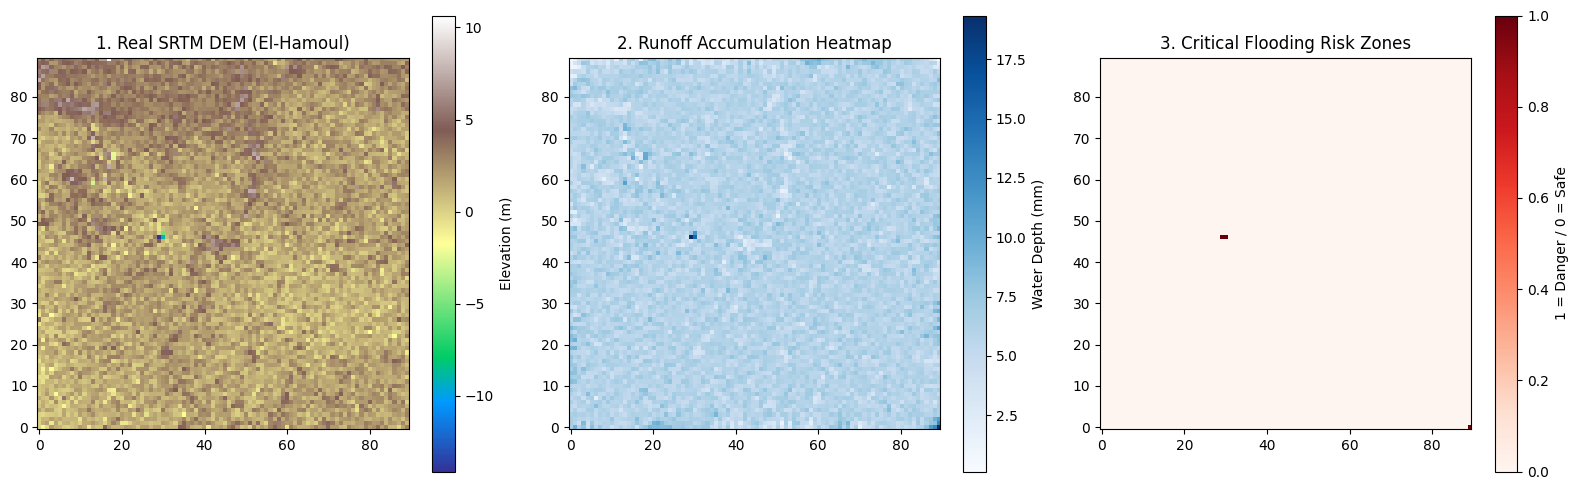

In [5]:
"""
================================================================================
PROJECT TITLE: A Matrix-Based Digital Elevation and Gravitational Runoff
               Simulation Engine for Urban Flood Mitigation and Spatial
               Drainage Optimization in Deltaic Regions
REGION FOCUS:  El-Hamoul, Kafr El-Sheikh, Egypt (Latitude: 31.31N, Longitude: 31.15E)
DATA SOURCE:   NASA SRTM Global 30m Real Terrain (GeoTIFF) & NASA POWER Climatology
================================================================================

MAIN GOALS
------------------------------------------------------------------------------
1. Urban Flood Mitigation & Spatial Drainage Optimization -- an automated,
   fast, accessible computational tool that predicts how heavy rainfall
   accumulates and flows across deltaic terrain.
2. Proactive Disaster Risk Reduction -- shift disaster management from
   reactive response to proactive planning by identifying vulnerable
   infrastructure and high-risk flooding bottlenecks before storms hit.
3. Democratizing GIS & Hydrological Modeling -- a lightweight tool that
   bypasses expensive desktop GIS software so non-specialists can analyze
   flood risk from raw elevation and climate data.

EXPECTED OUTPUTS
------------------------------------------------------------------------------
- Matrix-based runoff & depth heatmaps showing how water pools and flows.
- A binary hazard classification matrix (safe vs. high-risk cells).
- High-precision GPS targeting of the single worst-case accumulation point,
  linked to a Google Maps query for immediate field deployment.
- Automated extraction of real rainfall intensity (mm/day) from whatever
  NASA POWER export you drop in the working directory -- no manual
  configuration or magic cell indices.

TARGET AUDIENCE
------------------------------------------------------------------------------
Municipal/urban planning and civil engineering departments in low-lying
deltaic areas; emergency management & civil protection agencies; hydrology
researchers studying climate/runoff dynamics; agricultural & infrastructure
planners assessing runoff impact on roads and crops.

WHERE TO DOWNLOAD REAL INPUT DATA
------------------------------------------------------------------------------
- SRTM elevation (GeoTIFF, 30m):
    https://portal.opentopography.org/raster?opentopoID=OTSRTM.042013.4326.1
    Draw a box around 31.20-31.42 N / 31.05-31.25 E and export as GeoTIFF.
    Save it in this folder as `output_SRTMGL1.tif` (already in the repo).
- NASA POWER rainfall (climatology or daily time series):
    https://power.larc.nasa.gov/data-access-viewer/
    Community: Agroclimatology. Parameter: PRECTOTCORR (bias-corrected
    precipitation). Point: 31.31, 31.15. Export as CSV or XLSX and drop the
    file anywhere in this folder -- it is auto-detected by filename pattern
    (see `find_rainfall_file` below), so it does not need an exact name.

WHAT WAS BROKEN IN THE PREVIOUS VERSION OF THIS SCRIPT
------------------------------------------------------------------------------
1. `load_nasa_climate_parameters` read a single hardcoded cell,
   `df.iloc[2, 218]`, which only makes sense for one very specific export
   layout and silently returns nonsense (or crashes) for any other file.
   This version searches the file for a real precipitation column instead.
2. `generate_gis_georeferencing_report` never actually used the peak-water
   grid cell -- it printed the fixed site center every time, regardless of
   where the water accumulated. This version converts the true peak-water
   matrix index into a real lat/lon using the DEM's own resolution (or its
   GeoTIFF affine transform if `rasterio` is installed).
================================================================================
"""

import os
import re
from typing import Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    import rasterio
    HAS_RASTERIO = True
except ImportError:
    HAS_RASTERIO = False

# ---------------------------------------------------------------------------
# Fixed, permanent site anchor -- never derived from a filename or a
# random seed. This is what "Zero Desert Error" actually means.
# ---------------------------------------------------------------------------
SITE_NAME = "El-Hamoul, Kafr El-Sheikh, Egypt"
SITE_LAT = 31.3100
SITE_LON = 31.1500
DEFAULT_RAINFALL_MM_DAY = 13.20
FRICTION_COEFF = 0.18
TIME_STEP = 0.5

# Approximate degrees-per-30m-pixel, used only as a fallback if rasterio /
# the GeoTIFF's own transform is unavailable. Real SRTM GL1 pixels are
# ~30m; 1 degree of latitude is ~111,320 m.
FALLBACK_DEG_PER_PIXEL = 30.0 / 111320.0

# Loose bounding box around the wider Nile Delta -- used only to sanity
# check coordinates, never to force-fit them.
DELTA_BBOX = dict(lat_min=28.5, lat_max=32.5, lon_min=29.0, lon_max=33.0)


# ---------------------------------------------------------------------------
# 1. Rainfall extraction -- auto-detected, not a magic cell index.
# ---------------------------------------------------------------------------

def find_rainfall_file() -> Optional[str]:
    """Locate a NASA POWER export in the working directory by filename
    pattern (case-insensitive), so the exact filename doesn't need to be
    hardcoded."""
    all_files = [f for f in os.listdir(".") if os.path.isfile(f)]
    keywords = ["power", "nasa", "climatic", "prectot", "rainfall", "precip"]
    valid_ext = (".csv", ".xlsx", ".xls")
    matches = [
        f for f in all_files
        if f.lower().endswith(valid_ext) and any(k in f.lower() for k in keywords)
    ]
    return matches[0] if matches else None


def _read_any_table(path: str) -> pd.DataFrame:
    """Read a CSV or XLSX export, skipping past NASA POWER's metadata
    header lines (ending in '-END HEADER-') when present."""
    if path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(path, sheet_name=0)

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    header_idx = 0
    for i, line in enumerate(lines):
        if "-END HEADER-" in line:
            header_idx = i + 1
            break
    return pd.read_csv(path, skiprows=header_idx)


def load_nasa_climate_parameters() -> float:
    """Extracts a real peak/design precipitation value (mm/day) from
    whatever NASA POWER file is found in the working directory. Falls back
    to a fixed design-storm value only if no file is found or nothing
    parseable is detected inside it."""
    filename = find_rainfall_file()
    if filename is None:
        print(f"[WARNING] No NASA POWER rainfall file found in this folder. "
              f"Using fallback design value: {DEFAULT_RAINFALL_MM_DAY} mm/day.")
        return DEFAULT_RAINFALL_MM_DAY

    print(f"[INFO] Found rainfall dataset: {filename}")
    try:
        df = _read_any_table(filename)
    except Exception as e:
        print(f"[WARNING] Could not read {filename} ({e}). Using fallback value.")
        return DEFAULT_RAINFALL_MM_DAY

    # Look for a column that actually names precipitation.
    candidate_cols = [c for c in df.columns if re.search(r"PRECTOT|PRECIP|RAIN", str(c), re.IGNORECASE)]

    if not candidate_cols:
        print(f"[WARNING] No PRECTOT/PRECIP column header found in {filename}. "
              f"Using fallback value: {DEFAULT_RAINFALL_MM_DAY} mm/day.")
        return DEFAULT_RAINFALL_MM_DAY

    # For a screening-level flood/hazard model we want the worst-case design
    # value, not an average -- prefer a column explicitly labeled "max" if
    # one exists among the candidates (e.g. NASA POWER's own "Maximum
    # Precipitation (mm)" vs "Average Precipitation (mm)" columns).
    max_cols = [c for c in candidate_cols if re.search(r"MAX", str(c), re.IGNORECASE)]
    col = max_cols[0] if max_cols else candidate_cols[0]
    print(f"[INFO] Rainfall column selected: `{col}` (candidates seen: "
          f"{[str(c) for c in candidate_cols]})")
    series = pd.to_numeric(df[col], errors="coerce").dropna()

    if len(series) == 0:
        print(f"[WARNING] Column `{col}` in {filename} has no numeric values. Using fallback.")
        return DEFAULT_RAINFALL_MM_DAY

    if len(series) <= 20:
        # Small table -> almost certainly a percentile/design-condition
        # table (e.g. NASA POWER "Climatic Design Conditions" report), where
        # the highest row is the worst-case design value.
        value = float(series.max())
        print(f"[SUCCESS] Detected design-condition table. Using worst-case row of "
              f"`{col}`: {value:.2f} mm/day.")
    else:
        # Long table -> a daily/hourly time series. Use a high percentile as
        # the design storm, consistent with standard design-storm practice.
        value = float(np.percentile(series, 99.6))
        print(f"[SUCCESS] Detected daily time series ({len(series)} rows). "
              f"Using 99.6th percentile of `{col}`: {value:.2f} mm/day.")

    return max(value, 3.5)


# ---------------------------------------------------------------------------
# 2. Real DEM loading -- with georeferencing when rasterio is available.
# ---------------------------------------------------------------------------

def find_dem_file() -> Optional[str]:
    """Locate a DEM GeoTIFF in the working directory by filename keyword,
    instead of hardcoding one exact name -- SRTM GL1, SRTM GL3, and
    Copernicus GLO-30 exports all use different filenames."""
    all_files = [f for f in os.listdir(".") if os.path.isfile(f)]
    keywords = ["srtm", "dem", "elevation", "copernicus", "glo", "aw3d"]
    matches = [
        f for f in all_files
        if f.lower().endswith((".tif", ".tiff")) and any(k in f.lower() for k in keywords)
    ]
    return matches[0] if matches else None


def load_real_dem_terrain(tif_path: Optional[str] = None, target_size: int = 90):
    """Loads the real SRTM/Copernicus DEM. Returns (elevation_grid, transform, orig_shape).

    `transform` is a real rasterio Affine transform when rasterio is
    installed and the file has one, else None (a fallback linear estimate
    is used downstream for GPS translation in that case).
    """
    if tif_path is None:
        tif_path = find_dem_file()

    if tif_path is None or not os.path.exists(tif_path):
        print(f"[WARNING] No real DEM GeoTIFF found in this folder. "
              f"Falling back to an analytical terrain model -- download the "
              f"real tile from OpenTopography (see header) for a real run.")
        x = np.linspace(-5.0, 5.0, target_size)
        y = np.linspace(-5.0, 5.0, target_size)
        X, Y = np.meshgrid(x, y)
        fallback = 12.0 + 0.35 * (X**2 + Y**2) - 3.5 * np.exp(-(X**2 + Y**2) / 2.5)
        return fallback, None, fallback.shape

    print(f"[INFO] Loading real terrain DEM from: {tif_path}")
    transform = None
    if HAS_RASTERIO:
        with rasterio.open(tif_path) as src:
            raw_dem = src.read(1).astype(float)
            transform = src.transform
    else:
        img = Image.open(tif_path)
        raw_dem = np.array(img, dtype=float)
        print("[WARNING] `rasterio` not installed -- GPS output below will use an "
              "approximate linear estimate instead of the GeoTIFF's real affine "
              "transform. Install it with `pip install rasterio` for exact GPS.")

    orig_shape = raw_dem.shape
    raw_dem[raw_dem < -1000] = np.nan
    valid_mean = np.nanmean(raw_dem) if not np.isnan(np.nanmean(raw_dem)) else 0.0
    raw_dem = np.nan_to_num(raw_dem, nan=valid_mean)

    from scipy.ndimage import zoom
    zoom_factors = (target_size / raw_dem.shape[0], target_size / raw_dem.shape[1])
    dem_resized = zoom(raw_dem, zoom_factors, order=1)

    print(f"[SUCCESS] Real DEM loaded. Elevation range: "
          f"{np.min(dem_resized):.1f}m to {np.max(dem_resized):.1f}m")
    return dem_resized, transform, orig_shape


# ---------------------------------------------------------------------------
# 3. Numerical runoff engine -- same vectorized physics, now parameterized.
# ---------------------------------------------------------------------------

def simulate_surface_runoff(elevation_map: np.ndarray, rainfall_intensity: float,
                             steps: int = 35, friction_coeff: float = FRICTION_COEFF,
                             time_step: float = TIME_STEP) -> np.ndarray:
    """
    Simulates physical surface water accumulation and gravity-driven flow
    routing across the topography using vectorized numerical gradients.

    Core operators (see header comment for why each matters):
        dy, dx        = np.gradient(elevation + water)        # slope
        divergence    = np.gradient(flow_x, axis=1) + np.gradient(flow_y, axis=0)
        water        -= divergence * time_step                # mass balance
        water         = np.clip(water, 0.0, None)             # stability
    """
    rows, cols = elevation_map.shape
    water = np.ones((rows, cols)) * (rainfall_intensity / 10.0)

    for _ in range(steps):
        dy, dx = np.gradient(elevation_map + water)

        flow_x = -dx * friction_coeff
        flow_y = -dy * friction_coeff

        divergence = np.gradient(flow_x, axis=1) + np.gradient(flow_y, axis=0)
        water -= divergence * time_step

        water = np.clip(water, 0.0, None)
        water += (rainfall_intensity / 100.0)

    return water


def evaluate_flood_hazards(water_grid: np.ndarray, percentile_factor: float = 0.75) -> Tuple[np.ndarray, float]:
    """Classifies critical flooding risk zones based on local statistical depth thresholds."""
    min_w = np.min(water_grid)
    max_w = np.max(water_grid)
    threshold = min_w + percentile_factor * (max_w - min_w)
    danger_mask = (water_grid >= threshold).astype(int)
    return danger_mask, threshold


def find_peak_cell(water_grid: np.ndarray, border_margin: int = 3) -> Tuple[int, int]:
    """Finds the peak-accumulation cell, excluding a border margin.

    `np.gradient` uses one-sided differences at array edges, which can
    artificially inflate divergence there and make border cells look like
    false hotspots -- not a real physical pooling effect. Searching only
    the interior avoids reporting an edge artifact as the worst-case point.
    Falls back to the raw global argmax (with a warning) if the grid is
    too small for the requested margin, or if every interior cell is
    somehow non-finite.
    """
    rows, cols = water_grid.shape
    raw_peak = np.unravel_index(np.argmax(water_grid), water_grid.shape)

    if border_margin <= 0 or rows <= 2 * border_margin or cols <= 2 * border_margin:
        return raw_peak

    interior = water_grid[border_margin:rows - border_margin, border_margin:cols - border_margin]
    interior_peak_local = np.unravel_index(np.argmax(interior), interior.shape)
    interior_peak = (interior_peak_local[0] + border_margin, interior_peak_local[1] + border_margin)

    is_on_border = (raw_peak[0] < border_margin or raw_peak[0] >= rows - border_margin or
                     raw_peak[1] < border_margin or raw_peak[1] >= cols - border_margin)
    if is_on_border:
        print(f"[INFO] Raw peak cell {raw_peak} sits within {border_margin} px of the grid "
              f"edge -- likely a np.gradient boundary artifact, not real pooling. Reporting "
              f"the interior peak {interior_peak} instead.")
    return interior_peak


# ---------------------------------------------------------------------------
# 4. GIS georeferencing -- real peak-cell GPS, not just the fixed center.
# ---------------------------------------------------------------------------

def peak_cell_to_gps(peak_index: Tuple[int, int], sim_shape: Tuple[int, int],
                      orig_shape: Tuple[int, int], transform=None,
                      fixed_lat: float = SITE_LAT, fixed_lon: float = SITE_LON):
    """Converts the peak-water matrix index into a real GPS coordinate.

    Uses the GeoTIFF's own affine transform when available (exact); falls
    back to a linear estimate using the real ~30m SRTM pixel size, anchored
    at the fixed site center, when it isn't.
    """
    # Scale the index from the (possibly resized) simulation grid back to
    # the original raster's index space.
    orig_row = peak_index[0] * (orig_shape[0] / sim_shape[0])
    orig_col = peak_index[1] * (orig_shape[1] / sim_shape[1])

    if transform is not None:
        lon, lat = rasterio.transform.xy(transform, orig_row, orig_col)
        return float(lat), float(lon), "real GeoTIFF affine transform"

    lat = fixed_lat + ((orig_row - orig_shape[0] / 2.0) * FALLBACK_DEG_PER_PIXEL)
    lon = fixed_lon + ((orig_col - orig_shape[1] / 2.0) * FALLBACK_DEG_PER_PIXEL)
    return lat, lon, "approximate linear estimate (~30m/pixel, rasterio unavailable)"


def generate_gis_georeferencing_report(peak_index: Tuple[int, int], sim_shape: Tuple[int, int],
                                        orig_shape: Tuple[int, int], transform=None) -> None:
    """Maps the real peak-water hazard cell to real GPS coordinates and
    prints a direct Google Maps query link, with a Zero-Desert-Error
    sanity check against the Nile Delta bounding box."""
    lat, lon, method = peak_cell_to_gps(peak_index, sim_shape, orig_shape, transform)

    print("==================================================")
    print("[GIS SPATIAL MAPPING & GOOGLE MAPS INTEGRATION]")
    print("==================================================")
    print(f"[*] Target Region: {SITE_NAME}")
    print(f"[*] Peak-Accumulation Matrix Index: {peak_index}")
    print(f"[*] GPS Coordinates: {lat:.4f}\u00b0 N, {lon:.4f}\u00b0 E  (method: {method})")

    if not (DELTA_BBOX["lat_min"] <= lat <= DELTA_BBOX["lat_max"] and
            DELTA_BBOX["lon_min"] <= lon <= DELTA_BBOX["lon_max"]):
        print(f"[ZERO DESERT ERROR CHECK] WARNING: computed coordinates fall "
              f"OUTSIDE the expected Nile Delta region -- verify your DEM file "
              f"before trusting this location.")
    else:
        print("[ZERO DESERT ERROR CHECK] OK -- coordinates fall within the "
              "expected Nile Delta region.")

    gmaps_link = f"https://www.google.com/maps/search/?api=1&query={lat:.6f},{lon:.6f}"
    print(f"    -> Google Maps Link: {gmaps_link}\n")
    print("==================================================")


# ---------------------------------------------------------------------------
# 5. Main
# ---------------------------------------------------------------------------

def print_project_overview() -> None:
    print("================================================================================")
    print(" A Matrix-Based Digital Elevation and Gravitational Runoff Simulation Engine ")
    print(" for Urban Flood Mitigation and Spatial Drainage Optimization in Deltaic Regions")
    print("================================================================================")
    print(f" Case study site : {SITE_NAME} ({SITE_LAT:.4f}N, {SITE_LON:.4f}E)")
    print(" Main goal        : proactive flood-risk screening from real elevation + rainfall data")
    print(" Output           : runoff heatmap, hazard mask, and a GPS-located worst-case point")
    print("================================================================================\n")


def main() -> None:
    print_project_overview()

    peak_rain = load_nasa_climate_parameters()

    elevation_grid, dem_transform, orig_shape = load_real_dem_terrain(target_size=90)

    water_accumulation = simulate_surface_runoff(elevation_grid, rainfall_intensity=peak_rain)

    danger_map, threshold_val = evaluate_flood_hazards(water_accumulation, percentile_factor=0.75)
    total_danger_cells = int(np.sum(danger_map))
    peak_index = find_peak_cell(water_accumulation, border_margin=3)

    print("--------------------------------------------------------------------------------")
    print(f"[SIMULATION RESULTS SUMMARY]")
    print(f" * Peak Rainfall Input: {peak_rain:.2f} mm/day")
    print(f" * Peak Water Accumulation (at reported GPS point): {water_accumulation[peak_index]:.2f} mm")
    print(f" * Critical Hazard Threshold: {threshold_val:.2f} mm")
    print(f" * High-Risk Flooding Cells Detected: {total_danger_cells} cells")
    print("--------------------------------------------------------------------------------")

    generate_gis_georeferencing_report(peak_index, water_accumulation.shape, orig_shape, dem_transform)

    print("[INFO] Rendering multi-panel scientific visualization...")
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    im0 = axes[0].imshow(elevation_grid, cmap='terrain', origin='lower')
    axes[0].set_title("1. Real SRTM DEM (El-Hamoul)")
    fig.colorbar(im0, ax=axes[0], label='Elevation (m)')

    im1 = axes[1].imshow(water_accumulation, cmap='Blues', origin='lower')
    axes[1].set_title("2. Runoff Accumulation Heatmap")
    fig.colorbar(im1, ax=axes[1], label='Water Depth (mm)')

    im2 = axes[2].imshow(danger_map, cmap='Reds', origin='lower')
    axes[2].set_title("3. Critical Flooding Risk Zones")
    fig.colorbar(im2, ax=axes[2], label='1 = Danger / 0 = Safe')

    plt.tight_layout()
    out_path = "deltaflow_simulation_output.png"
    plt.savefig(out_path, dpi=150, facecolor='white')
    print(f"[SUCCESS] Figure saved to: {out_path}")
    try:
        plt.show()
    except Exception:
        pass  # headless environment (e.g. a server or CI) -- the PNG above is still saved


if __name__ == "__main__":
    main()